## Torso Kinematics

In [1]:
import numpy as np
import kinematics_utils as ku
import matplotlib.pyplot as plt
import matplotlib.patches as patches

In [2]:
# Lengths
l_fixed = 25.0
l_crank = 75.0
l_rod = 115.0

# Spacing
l_spacing_crank = 80.0
l_spacing_rod = 80.0
l_spacing_base = 80.0
l_spacing_torso = 80.0
l_diff = l_rod - l_fixed

crank_angle = np.radians(0.0)
rod_angle = np.radians(90.0)

O = np.array([0.0, 0.0, 0.0])
rA1_H = np.array([0.0, +l_spacing_crank / 2.0, l_diff + l_crank * np.sin(crank_angle)])
rA2_H = np.array([0.0, -l_spacing_crank / 2.0, l_diff + l_crank * np.sin(crank_angle)])
rB1_H = np.array([l_crank * np.cos(crank_angle), +l_spacing_rod / 2.0, l_diff])
rB2_H = np.array([l_crank * np.cos(crank_angle), -l_spacing_rod / 2.0, l_diff])
rC1_H = np.array([l_crank * np.cos(crank_angle) + l_rod * np.cos(rod_angle),+l_spacing_base / 2.0,-l_fixed,])
rC2_H = np.array([l_crank * np.cos(crank_angle) + l_rod * np.cos(rod_angle),-l_spacing_base / 2.0,-l_fixed,])
rD1_H = np.array([0.0, +l_spacing_torso / 2.0, 0.0])
rD2_H = np.array([0.0, -l_spacing_torso / 2.0, 0.0])

#### Visualization - Home, Links

In [3]:
point_style_ = {
    "O": "r",
    "A1": "r", "A2": "r",
    "B1": "r", "B2": "r",
    "C1": "r", "C2": "r",
    "D1": "r", "D2": "r",
    "A1H": "b", "A2H": "b",
    "B1H": "b", "B2H": "b",
    "D1H": "b", "D2H": "b",
}

links_ = [
    ("A1", "B1"),
    ("A2", "B2"),
    ("B1", "C1"),
    ("B2", "C2"),
    ("A1", "A2"),
    ("D1", "O"),
    ("D2", "O"),
    ("A1", "D1"),
    ("A2", "D2"),
]

fixed_ = [
    ("C1", "C2"),
    ("C1", "D1H"),
    ("C2", "D2H"),
    ("D1H", "D2H"),
]

home_ = [
    ("O", "D1H"),
    ("O", "D2H"),
    ("A1H", "A2H"),
    ("A1H", "B1H"),
    ("B1H", "C1"),
    ("B2H", "C2"),
    ("A2H", "B2H"),
    ("D1H", "A1H"),
    ("D2H", "A2H"),
]

planes_ = [
    {
        "points": ("A1", "A2", "D2", "D1"),
        "color": "yellow",
        "alpha": 0.5,
        "views": ("ax1", "ax2"),
    },
    {
        "points": ("D1H", "C1", "C2", "D2H"),
        "color": "cyan",
        "alpha": 0.5,
        "views": ("ax1", "ax2"),
    },
]

In [4]:
def solve_and_plot(roll_deg, pitch_deg):

    pitch = np.radians(pitch_deg)
    roll = np.radians(roll_deg)

    R = ku.Ry(pitch) @ ku.Rx(roll)

    # Rotated points
    rA1 = R @ rA1_H
    rA2 = R @ rA2_H
    rB1_i = R @ rB1_H
    rB2_i = R @ rB2_H
    rD1 = R @ rD1_H
    rD2 = R @ rD2_H

    # Rotation axis
    axis = rA1 - rA2
    axis /= np.linalg.norm(axis)

    # IK
    theta1_candidates = ku.solve_theta(rC1_H, rA1, rB1_i, l_rod, axis)
    theta2_candidates = ku.solve_theta(rC2_H, rA2, rB2_i, l_rod, axis)

    if not theta1_candidates or not theta2_candidates:
        print("❌ No IK solution")
        return

    theta1 = theta1_candidates[1]
    theta2 = theta2_candidates[1]

    rB1 = rA1 + ku.rot_axis(axis, theta1) @ (rB1_i - rA1)
    rB2 = rA2 + ku.rot_axis(axis, theta2) @ (rB2_i - rA2)

    print(f"Roll = {roll_deg}°Pitch = {pitch_deg}°, \n")
    print(f"θ1 = {np.degrees(theta1):.6f}°")
    print(f"θ2 = {np.degrees(theta2):.6f}°")

    points = {
        "O": O,
        "A1": rA1,
        "A2": rA2,
        "B1": rB1,
        "B2": rB2,
        "C1": rC1_H,
        "C2": rC2_H,
        "D1": rD1,
        "D2": rD2,
        "A1H": rA1_H,
        "A2H": rA2_H,
        "B1H": rB1_H,
        "B2H": rB2_H,
        "D1H": rD1_H,
        "D2H": rD2_H,
    }

    ku.visualize_mechanism(points, point_style_, links_, fixed_, home_, planes_)

Roll = 0.0°Pitch = 0.0°, 

θ1 = 0.000000°
θ2 = 0.000000°


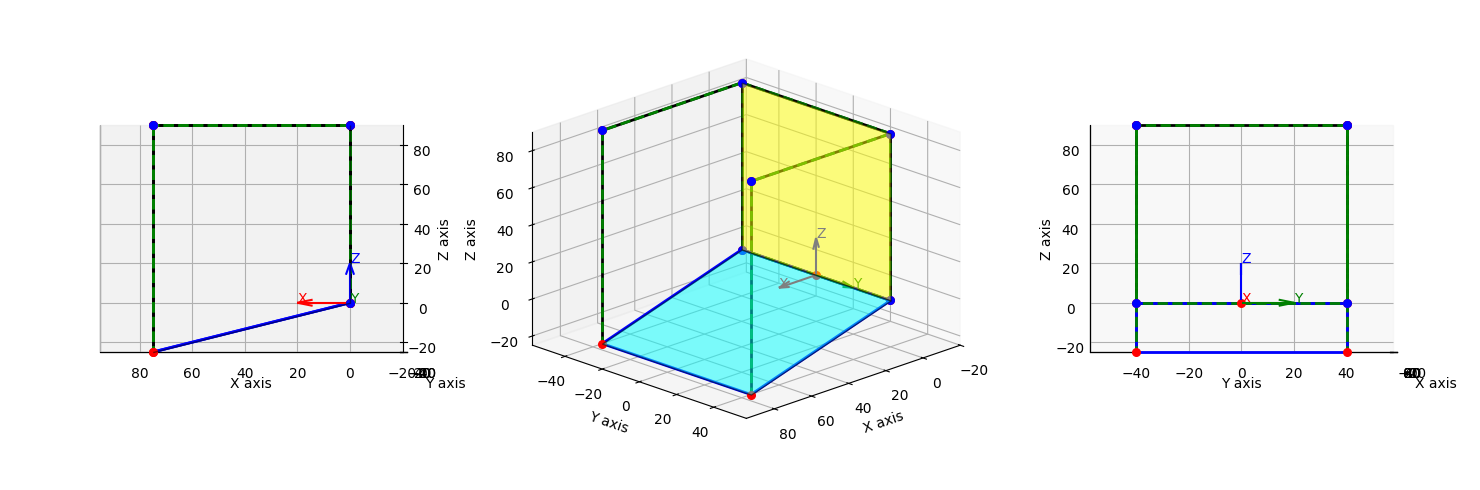

In [9]:
solve_and_plot(roll_deg=0.0, pitch_deg=0.0)

### Workspace Analysis

In [6]:
def is_feasible(pitch_deg, roll_deg):
    pitch = np.radians(pitch_deg)
    roll = np.radians(roll_deg)

    R = ku.Ry(pitch) @ ku.Rx(roll)

    # Rotate points
    rA1 = R @ rA1_H
    rA2 = R @ rA2_H
    rB1_i = R @ rB1_H
    rB2_i = R @ rB2_H

    # Rotation axis
    axis = rA1 - rA2
    axis /= np.linalg.norm(axis)

    # IK solve
    theta1 = ku.solve_theta(rC1_H, rA1, rB1_i, l_rod, axis)
    theta2 = ku.solve_theta(rC2_H, rA2, rB2_i, l_rod, axis)

    return bool(theta1) and bool(theta2)

In [7]:
pitch_vals = np.linspace(-90, 90, 200)
roll_vals = np.linspace(-90, 90, 200)

feasible_x, feasible_y = [], []
infeasible_x, infeasible_y = [], []

for pitch in pitch_vals:
    for roll in roll_vals:
        if is_feasible(pitch, roll):
            feasible_x.append(pitch)
            feasible_y.append(roll)
        else:
            infeasible_x.append(pitch)
            infeasible_y.append(roll)

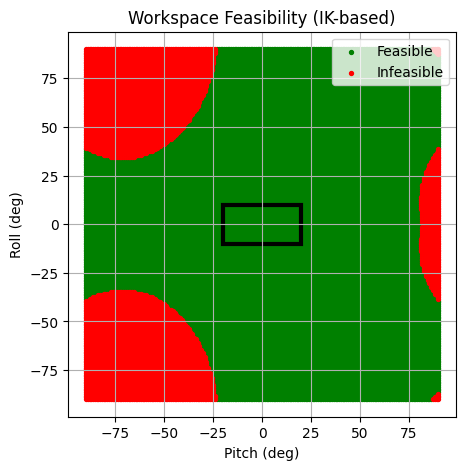

In [8]:
fig, ax = plt.subplots(figsize=(5, 5))
ax.scatter(feasible_x, feasible_y, c="green", s=8, label="Feasible")
ax.scatter(infeasible_x, infeasible_y, c="red", s=8, label="Infeasible")

#  Target workspace box
target_pitch_min, target_pitch_max = -20, 20
target_roll_min, target_roll_max = -10, 10

rect = patches.Rectangle(
    (target_pitch_min, target_roll_min),
    target_pitch_max - target_pitch_min,
    target_roll_max - target_roll_min,
    linewidth=3,
    edgecolor="black",
    facecolor="none",
)

ax.add_patch(rect)

ax.set_xlabel("Pitch (deg)")
ax.set_ylabel("Roll (deg)")
ax.set_title("Workspace Feasibility (IK-based)")
ax.legend()
ax.grid(True)

plt.show()